# 02 ? Leakage-safe model experiments

**Problem:** predict binary survival in the Titanic benchmark. **Audience:** technical recruiters and data practitioners. **Input:** audited official manifest fields. **Transformation:** fold-safe pipelines, shared repeated cross-validation, group robustness checks, bounded tuning, ablations, threshold analysis, and an optional soft vote. **Output:** one locked classifier and a validated submission artifact. **Value:** the final choice is supported by stable local evidence rather than leaderboard feedback.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
METRICS = ROOT / "reports" / "metrics"
FIGURES = ROOT / "reports" / "figures"
selected = json.loads((METRICS / "final_model_selection.json").read_text())
models = pd.read_csv(METRICS / "model_comparison.csv")
ablations = pd.read_csv(METRICS / "feature_ablation.csv")
robustness = pd.read_csv(METRICS / "group_robustness.csv")
ensemble = json.loads((METRICS / "ensemble_analysis.json").read_text())
submissions = pd.read_csv(ROOT / "reports" / "submission_log.csv")
submitted = submissions.loc[submissions["submission_ref"].notna()].iloc[-1]
{
    "locked_model": selected["name"],
    "feature_set": selected["feature_set"],
    "threshold": selected["threshold"],
    "repeated_cv_accuracy": round(selected["primary_validation"]["accuracy_mean"], 4),
    "repeated_cv_std": round(selected["primary_validation"]["accuracy_std"], 4),
    "kaggle_submission_ref": int(submitted["submission_ref"]),
    "kaggle_public_score": float(submitted["kaggle_public_score"]),
}

{'locked_model': 'hist_gradient_boosting',
 'feature_set': 'basic',
 'threshold': 0.575,
 'repeated_cv_accuracy': 0.8323,
 'repeated_cv_std': 0.0231,
 'kaggle_submission_ref': 54982397,
 'kaggle_public_score': 0.77033}

## Shared-fold model comparison

Every candidate used the same 25 primary folds. CatBoost and HistGradientBoosting were the two strongest advanced candidates and each received 12 randomized configurations over five tuning folds. Logistic regression remained a strong transparent comparator. Differences are small relative to fold variation, so the selection rule treats gains below 0.003 as practical ties.

In [2]:
columns = ["model", "accuracy_mean", "accuracy_std", "balanced_accuracy_mean", "f1_mean"]
models.loc[:, columns].round(4)

,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,f1_mean
0,gender_rule,0.7867,0.0267,0.7669,0.7094
1,dummy,0.6162,0.0023,0.5000,0.0000
2,logistic,0.8258,0.0248,0.8069,0.7611
3,extra_trees,0.8222,0.0269,0.7991,0.7501
4,catboost_selected_config,0.8263,0.0230,0.8051,0.7586
5,hist_gradient_boosting_selected_config,0.8280,0.0241,0.8076,0.7621
6,catboost,0.8271,0.0207,0.8044,0.7574
7,hist_gradient_boosting,0.8256,0.0224,0.8044,0.7574


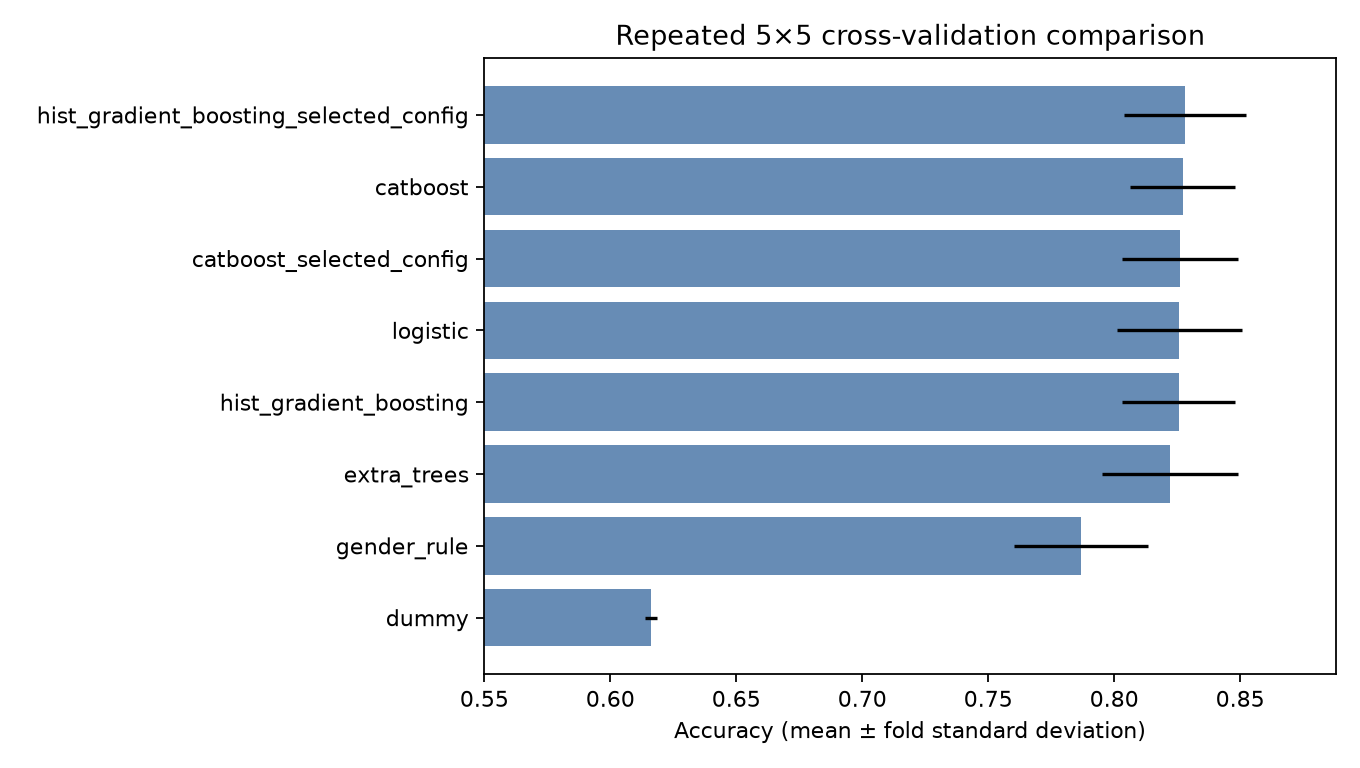

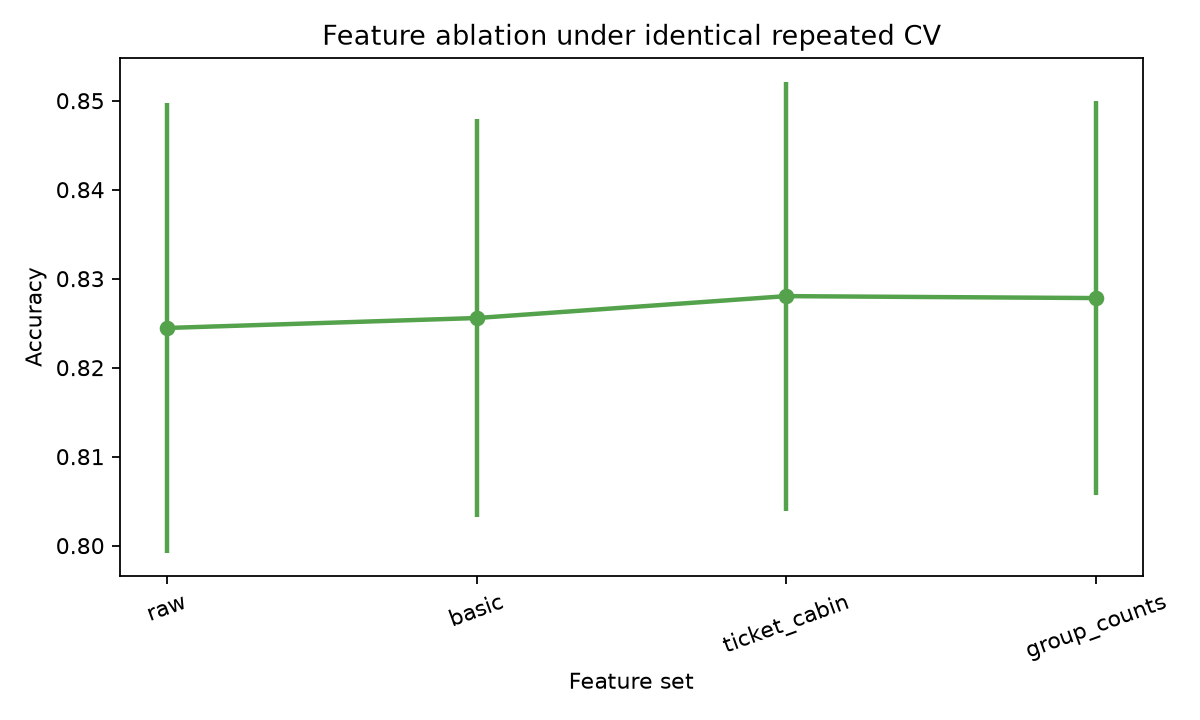

In [3]:
display(Image(filename=str(FIGURES / "model_cv_comparison.png"), width=840))
display(Image(filename=str(FIGURES / "feature_ablation.png"), width=760))

## Feature, threshold, and ensemble decisions

The ticket/cabin set had the highest unthresholded ablation mean, but its 0.0025 gain over raw fields was inside the practical-tie margin. Fold-fitted group counts added no primary gain and weakened both group diagnostics. The simpler basic set was retained. Threshold 0.575 improved four of five repeats. The best soft vote failed the qualification rule and was rejected.

In [4]:
display(ablations[["feature_set", "feature_count", "accuracy_mean", "accuracy_std", "family_group_accuracy", "ticket_group_accuracy"]].round(4))
{
    "ensemble_weights_hist_cat": ensemble["weights"],
    "gain_over_best_single": round(ensemble["gain_over_best_single_repeat_mean"], 4),
    "repeat_improvements": ensemble["repeat_improvements"],
    "qualifies": ensemble["qualifies"],
}

,feature_set,feature_count,accuracy_mean,accuracy_std,family_group_accuracy,ticket_group_accuracy
0,raw,7,0.8245,0.0252,0.8092,0.8081
1,basic,18,0.8256,0.0224,0.8193,0.8125
2,ticket_cabin,22,0.8280,0.0241,0.8261,0.8204
3,group_counts,28,0.8278,0.0221,0.8003,0.7946


{'ensemble_weights_hist_cat': [0.25, 0.75],
 'gain_over_best_single': -0.0018,
 'repeat_improvements': 2,
 'qualifies': False}

## Robustness, errors, and interpretation

The locked model reaches 0.8323 ? 0.0231 in repeated stratified CV, 0.8204 ? 0.0286 when family groups cannot cross folds, 0.8282 ? 0.0250 for ticket groups, and 0.8249 ? 0.0302 under a second seed. Its averaged out-of-fold confusion matrix contains 514 true negatives, 35 false positives, 121 false negatives, and 221 true positives. Importance is fold-aggregated permutation importance: predictive association, not causality.

,validation,accuracy_mean,accuracy_std,balanced_accuracy_mean,f1_mean
0,RepeatedStratifiedKFold 5x5,0.8323,0.0231,0.8022,0.7538
1,Family groups,0.8204,0.0286,0.7910,0.7397
2,Ticket groups,0.8282,0.0250,0.7955,0.7440


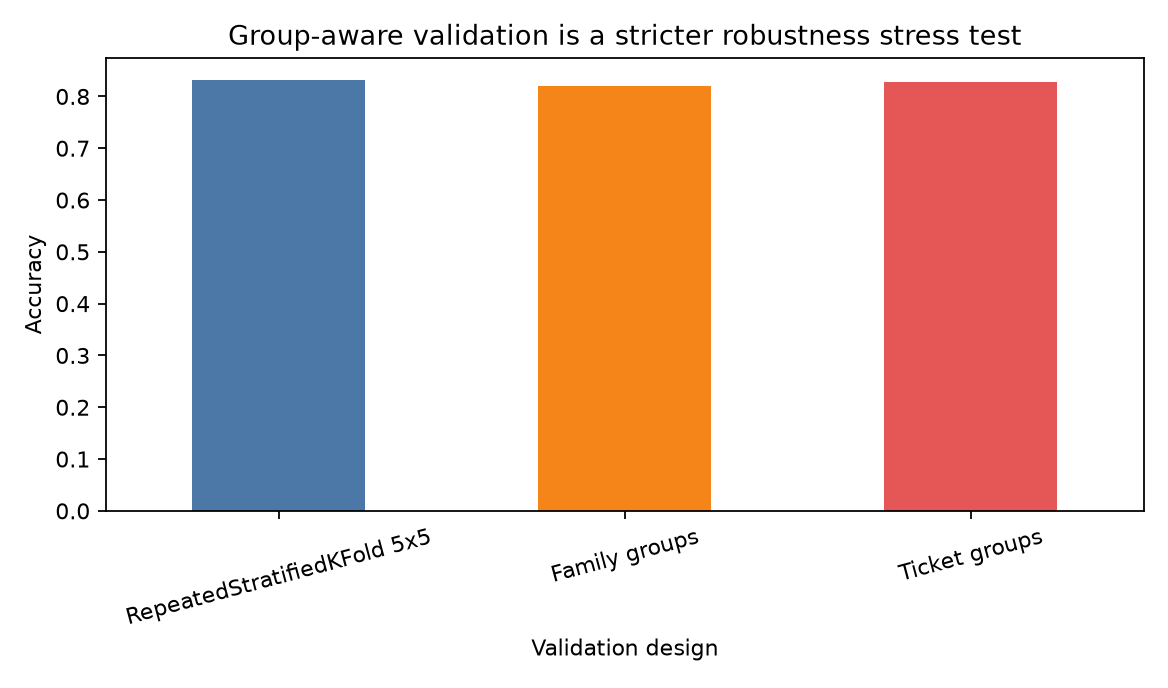

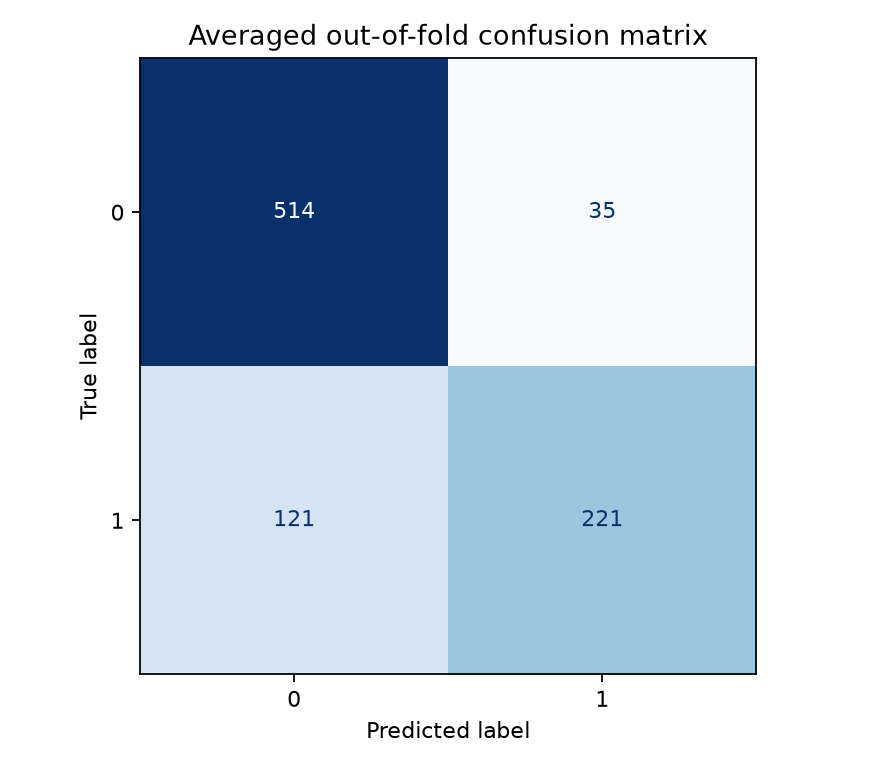

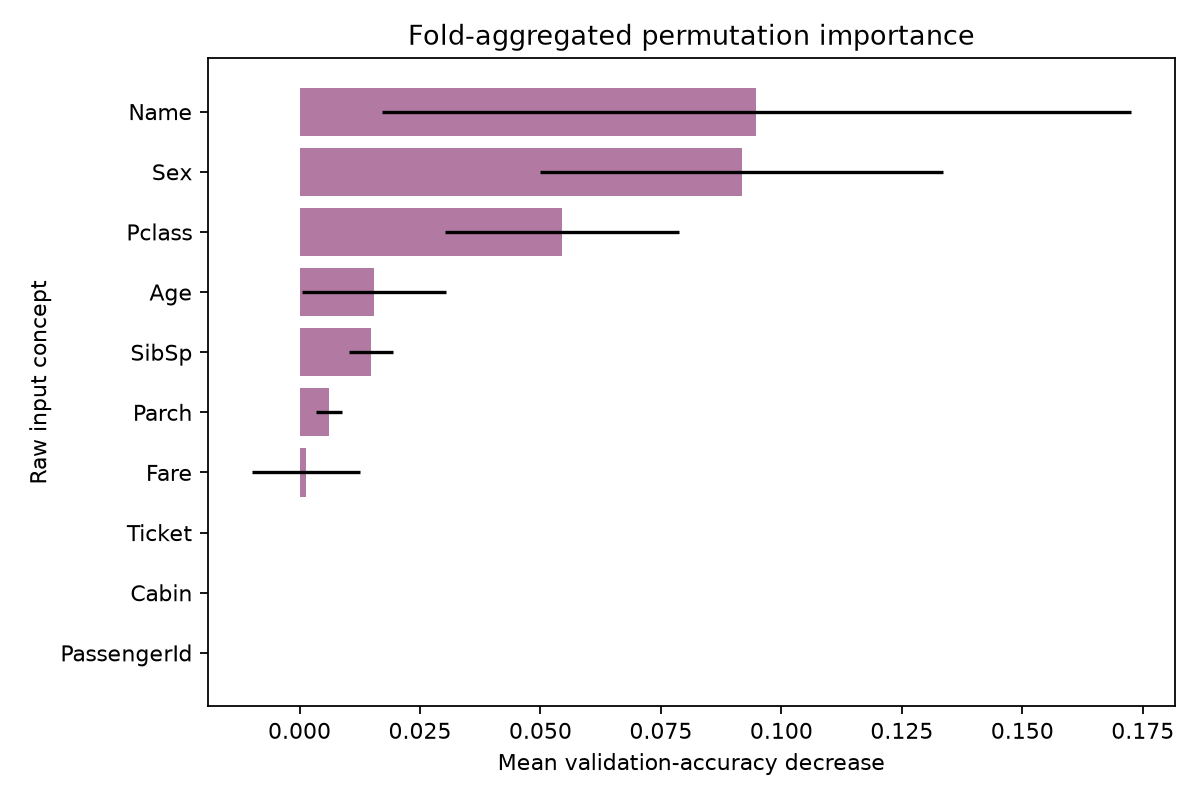

In [5]:
display(robustness[["validation", "accuracy_mean", "accuracy_std", "balanced_accuracy_mean", "f1_mean"]].round(4))
display(Image(filename=str(FIGURES / "group_robustness.png"), width=760))
display(Image(filename=str(FIGURES / "confusion_matrix.png"), width=560))
display(Image(filename=str(FIGURES / "feature_importance.png"), width=760))

## Locked conclusion and Kaggle result

The final artifact is HistGradientBoosting on 18 deterministic basic features at threshold 0.575. The decision was frozen before Kaggle submission. Submission **54982397** completed with public score **0.77033**; this hidden-label measurement is distinct from local cross-validation and caused no retuning. No external data, transductive counts, hidden labels, copied predictions, target-derived group priors, or leaderboard-guided changes were used. This small historical benchmark demonstrates methodology; it is not suitable for contemporary safety decisions.